1. Change no. of inputs
2. Change the parameters

Step-by-step RNN computation:

Time step 1:
Input x_1 = 1.0
h_1 = tanh(0.5*1.0 + 0.8*0.0) = 0.4621

Final Hidden States: [np.float64(0.46211715726000974)]
Time step 2:
Input x_2 = 2.0
h_2 = tanh(0.5*2.0 + 0.8*0.46211715726000974) = 0.8786

Final Hidden States: [np.float64(0.46211715726000974), np.float64(0.8786223746838898)]
Time step 3:
Input x_3 = 3.0
h_3 = tanh(0.5*3.0 + 0.8*0.8786223746838898) = 0.9759

Final Hidden States: [np.float64(0.46211715726000974), np.float64(0.8786223746838898), np.float64(0.9758816208890569)]


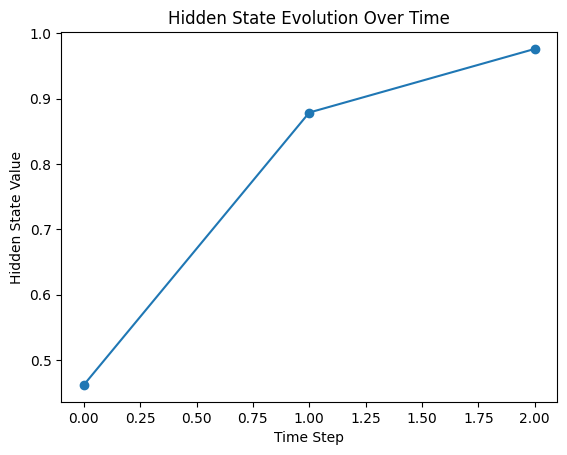

In [ ]:
import numpy as np
# Sequence: x1, x2, x3
X = [1.0, 2.0, 3.0]
# Weight matrices (scalar case for simplicity)
Wx = 0.5   # input weight
Wh = 0.8   # hidden weight
b = 0.0    # bias

# Initial hidden state
h_prev = 0.0
def tanh(x):
    return np.tanh(x)
hidden_states = []

print("Step-by-step RNN computation:\n")

for t, x_t in enumerate(X):
    h_t = tanh(Wx * x_t + Wh * h_prev + b)

    print(f"Time step {t+1}:")
    print(f"Input x_{t+1} = {x_t}")
    print(f"h_{t+1} = tanh({Wx}*{x_t} + {Wh}*{h_prev}) = {h_t:.4f}\n")

    hidden_states.append(h_t)
    h_prev = h_t
    print("Final Hidden States:", hidden_states)

import matplotlib.pyplot as plt

plt.plot(hidden_states, marker='o')
plt.title("Hidden State Evolution Over Time")
plt.xlabel("Time Step")
plt.ylabel("Hidden State Value")
plt.show()

Step-by-step RNN computation:

Time step 1:
Input x_1 = 1.0
h_1 = tanh(0.8*1.0 + 0.5*0.0) = 0.6640

Final Hidden States: [np.float64(0.664036770267849)]
Time step 2:
Input x_2 = 2.0
h_2 = tanh(0.8*2.0 + 0.5*0.664036770267849) = 0.9589

Final Hidden States: [np.float64(0.664036770267849), np.float64(0.9588962368206502)]
Time step 3:
Input x_3 = 3.0
h_3 = tanh(0.8*3.0 + 0.5*0.9588962368206502) = 0.9937

Final Hidden States: [np.float64(0.664036770267849), np.float64(0.9588962368206502), np.float64(0.9937106571090586)]
Time step 4:
Input x_4 = 4.0
h_4 = tanh(0.8*4.0 + 0.5*0.9937106571090586) = 0.9988

Final Hidden States: [np.float64(0.664036770267849), np.float64(0.9588962368206502), np.float64(0.9937106571090586), np.float64(0.9987705377455537)]
Time step 5:
Input x_5 = 5.0
h_5 = tanh(0.8*5.0 + 0.5*0.9987705377455537) = 0.9998

Final Hidden States: [np.float64(0.664036770267849), np.float64(0.9588962368206502), np.float64(0.9937106571090586), np.float64(0.9987705377455537), np.float64(0

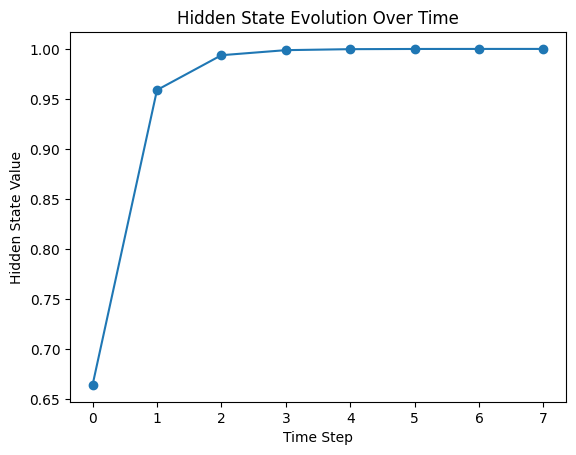

In [ ]:
import numpy as np
# Sequence: x1, x2, x3
X = [1.0, 2.0, 3.0 , 4.0 , 5.0 , 6.0 , 7.0 , 8.0]
# Weight matrices (scalar case for simplicity)
Wx = 0.8  # input weight
Wh = 0.5 # hidden weight
b = 0.0    # bias

# Initial hidden state
h_prev = 0.0
def tanh(x):
    return np.tanh(x)
hidden_states = []

print("Step-by-step RNN computation:\n")

for t, x_t in enumerate(X):
    h_t = tanh(Wx * x_t + Wh * h_prev + b)

    print(f"Time step {t+1}:")
    print(f"Input x_{t+1} = {x_t}")
    print(f"h_{t+1} = tanh({Wx}*{x_t} + {Wh}*{h_prev}) = {h_t:.4f}\n")

    hidden_states.append(h_t)
    h_prev = h_t
    print("Final Hidden States:", hidden_states)

import matplotlib.pyplot as plt

plt.plot(hidden_states, marker='o')
plt.title("Hidden State Evolution Over Time")
plt.xlabel("Time Step")
plt.ylabel("Hidden State Value")
plt.show()

1. CHANGE THE PARAMETERS
2. CHNAGE THE NO. OF INPUTS

In [ ]:
import numpy as np

# -------------------------
# 1. Input sequence
# -------------------------
X = [1.0, 2.0, 3.0 , 4.0 , 5.0 , 6.0 , 7.0 , 8.0 , 9.0 , 10]
target = 0.5   # desired output

# -------------------------
# 2. Initialize parameters
# -------------------------
Wx = 0.8
Wh = 0.5
Wy = 1.0
b = 0.0

# Learning rate
lr = 0.01

# -------------------------
# 3. Activation functions
# -------------------------
def tanh(x):
    return np.tanh(x)

def dtanh(x):
    return 1 - np.tanh(x)**2

# -------------------------
# 4. Forward Pass
# -------------------------
h = [0.0]   # h0 = 0

for t in range(len(X)):
    h_t = tanh(Wx * X[t] + Wh * h[t] + b)
    h.append(h_t)

# Output (many-to-one)
y_pred = Wy * h[-1]

# Loss (Mean Squared Error)
loss = 0.5 * (y_pred - target)**2

print("Forward Pass:")
print("Hidden states:", h[1:])
print("Prediction:", y_pred)
print("Loss:", loss)

# -------------------------
# 5. Backward Pass (BPTT)
# -------------------------

# Gradients initialization
dWx = 0
dWh = 0
dWy = 0
db = 0

# Output gradient
dy = (y_pred - target)

# Gradient for Wy
dWy = dy * h[-1]

# Backprop through time
dh_next = dy * Wy   # gradient flowing into last hidden state

for t in reversed(range(len(X))):

    # derivative of tanh
    dt = dtanh(Wx * X[t] + Wh * h[t] + b)

    # current gradient
    dh = dh_next * dt
    print(f"\nTime step {t}")
    print("dh:", dh)
    # accumulate gradients
    dWx += dh * X[t]
    dWh += dh * h[t]
    db  += dh

    # pass gradient backward in time
    dh_next = dh * Wh
      # PRINT AFTER UPDATING dh_next
    print("dh_next:", dh_next)
print("\nGradients:")
print("dWx:", dWx)
print("dWh:", dWh)
print("dWy:", dWy)
print("db:", db)

# -------------------------
# 6. Update weights
# -------------------------
Wx -= lr * dWx
Wh -= lr * dWh
Wy -= lr * dWy
b  -= lr * db

print("\nUpdated Parameters:")
print("Wx:", Wx)
print("Wh:", Wh)
print("Wy:", Wy)
print("b:", b)



Forward Pass:
Hidden states: [np.float64(0.664036770267849), np.float64(0.9588962368206502), np.float64(0.9937106571090586), np.float64(0.9987705377455537), np.float64(0.9997529072809926), np.float64(0.9999501569080843), np.float64(0.9999899386379222), np.float64(0.9999979687186837), np.float64(0.9999995898943359), np.float64(0.9999999172012151)]
Prediction: 0.9999999172012151
Loss: 0.12499995860061096

Time step 9
dh: 8.279876778647344e-08
dh_next: 4.139938389323672e-08

Time step 8
dh: 3.395623668597899e-14
dh_next: 1.6978118342989494e-14

Time step 7
dh: 6.897459909662392e-20
dh_next: 3.448729954831196e-20

Time step 6
dh: 6.939749244988264e-25
dh_next: 3.469874622494132e-25

Time step 5
dh: 3.458899391628192e-29
dh_next: 1.729449695814096e-29

Time step 4
dh: 8.545632642246767e-33
dh_next: 4.2728163211233835e-33

Time step 3
dh: 1.0500074081271325e-35
dh_next: 5.250037040635663e-36

Time step 2
dh: 6.583089668372956e-38
dh_next: 3.291544834186478e-38

Time step 1
dh: 2.650286300366

1. CHANGE BATCH SIZE
2. CHANGE HIDDEN STATE
3. CHANGE THE LEARNING RATE
4. CHANGE THE VOCAB SIZE : 2000, 1000 , 1500

In [ ]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense


vocab_size = 5000
max_len = 200
embed_size=32
hidden_size=32

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embed_size, input_length=max_len),
    SimpleRNN(hidden_size),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    verbose=1
)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy*100:.2f}%")

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.6550 - loss: 0.6185
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.6829 - loss: 0.5921
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.7471 - loss: 0.5061
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.7610 - loss: 0.4964
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.7888 - loss: 0.4490
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.8460 - loss: 0.3515
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - accuracy: 0.8656 - loss: 0.3092
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.8436 - loss: 0.3609
Epoch 9/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.9064 - loss: 0.2401
Epoch 10/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.9193 - loss: 0.2096
Epoch 11/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.9201 - loss: 0.2062
Epoch 12/20
782/782 ━━━━━━━━━━

In [ ]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.optimizers import Adam


vocab_size = 2000
max_len = 200
embed_size=32
hidden_size=64

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embed_size, input_length=max_len),
    SimpleRNN(hidden_size),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.01),
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    verbose=1
)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy*100:.2f}%")

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - accuracy: 0.5910 - loss: 0.6571
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.6380 - loss: 0.6173
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 52ms/step - accuracy: 0.6486 - loss: 0.6149
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.6670 - loss: 0.6051
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.6225 - loss: 0.6343
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.6452 - loss: 0.6089
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.6633 - loss: 0.5925
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.6661 - loss: 0.5935
Epoch 9/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.6748 - loss: 0.5797
Epoch 10/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.6815 - loss: 0.5752
Epoch 11/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 55ms/step - accuracy: 0.6903 - loss: 0.5708
Epoch 12/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 